# 8.4 — SABR: aproximación de Hagan y calibración

**SABR** (Hagan, Kumar, Lesniewski, Woodward, 2002) modela directamente la tasa forward
bajo la medida forward — natural para smiles de tasas (caps/swaptions), a diferencia de
Heston (8.3, modela el spot bajo la medida risk-neutral). Su fórmula de vol Black
implícita es una aproximación asintótica cerrada, de uso casi universal como convención
de mercado para cotizar smiles de tasas.

## 0. Configuración

In [1]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

from qflib.market import synthetic_cap_vols
from qflib.plotting import apply_style

apply_style()

## 1. SDE y la aproximación de Hagan

$$dF_t = \alpha_t F_t^\beta\,dW_t^F, \qquad d\alpha_t = \nu\alpha_t\,dW_t^\alpha,
\qquad d\langle W^F,W^\alpha\rangle_t=\rho\,dt$$

$\beta$ fija el tipo de "backbone" (0=normal, 1=lognormal, 0.5 típico de tasas) y por
convención de mercado **no se calibra** — se fija por convención del activo. La
**aproximación de Hagan** (expansión singular-perturbativa en $T$, derivación fuera de
alcance) da la vol Black implícita en forma cerrada:

$$\sigma_B(K,T) = \frac{\alpha}{(FK)^{\frac{1-\beta}{2}}\left[1+\frac{(1-\beta)^2}{24}\ln^2\frac{F}{K}+\frac{(1-\beta)^4}{1920}\ln^4\frac{F}{K}\right]}\cdot\frac{z}{x(z)}\cdot\left[1+\left(\frac{(1-\beta)^2}{24}\frac{\alpha^2}{(FK)^{1-\beta}}+\frac{\rho\beta\nu\alpha}{4(FK)^{\frac{1-\beta}{2}}}+\frac{2-3\rho^2}{24}\nu^2\right)T\right]$$

con $z=\frac{\nu}{\alpha}(FK)^{\frac{1-\beta}{2}}\ln\frac{F}{K}$ y
$x(z)=\ln\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}$; en $K\to F$ (ATM) la fórmula tiene
una forma límite separada (evita la indeterminación $0/0$ de $z/x(z)$).

In [2]:
def sabr_hagan_vol(F, K, T, alpha, beta, rho, nu):
    '''Vol Black implicita SABR, aproximacion de Hagan et al. (2002).'''
    if abs(F - K) < 1e-12:
        term1 = alpha / (F ** (1 - beta))
        term2 = 1 + ((1 - beta) ** 2 / 24 * alpha ** 2 / F ** (2 - 2 * beta)
                      + 0.25 * rho * beta * nu * alpha / F ** (1 - beta)
                      + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
        return term1 * term2
    FK = F * K
    logFK = np.log(F / K)
    FK_beta = FK ** ((1 - beta) / 2)
    z = (nu / alpha) * FK_beta * logFK
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    term1 = alpha / (FK_beta * (1 + (1 - beta) ** 2 / 24 * logFK ** 2 + (1 - beta) ** 4 / 1920 * logFK ** 4))
    term2 = z / x_z
    term3 = 1 + ((1 - beta) ** 2 / 24 * alpha ** 2 / FK ** (1 - beta)
                  + 0.25 * rho * beta * nu * alpha / FK_beta
                  + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
    return term1 * term2 * term3


def sabr_beta1_vol(F, K, T, alpha, rho, nu):
    '''Caso especial beta=1 (SABR lognormal), forma simplificada -- control del limite general.'''
    if abs(F - K) < 1e-12:
        term2 = 1 + (0.25 * rho * nu * alpha + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
        return alpha * term2
    logFK = np.log(F / K)
    z = (nu / alpha) * logFK
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    term3 = 1 + (0.25 * rho * nu * alpha + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
    return alpha * (z / x_z) * term3

### Demo 1 — smile SABR: efecto de $\rho$ y $\nu$

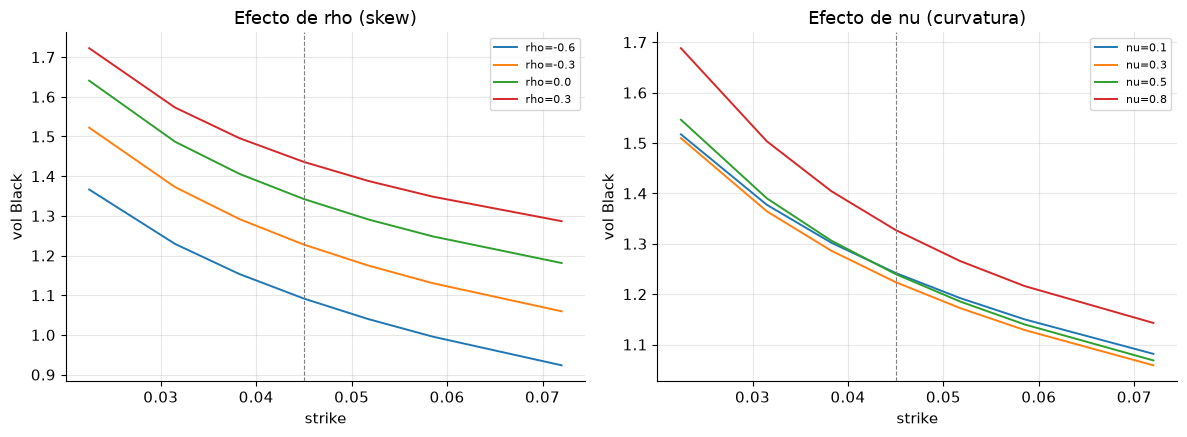

In [3]:
F0, T_demo = 0.045, 5.0
strikes_demo = F0 * np.array([0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.6])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for rho_i in [-0.6, -0.3, 0.0, 0.3]:
    vols = [sabr_hagan_vol(F0, K, T_demo, 0.25, 0.5, rho_i, 0.4) for K in strikes_demo]
    axes[0].plot(strikes_demo, vols, label=f"rho={rho_i}")
axes[0].axvline(F0, color="gray", ls="--", lw=0.8)
axes[0].set_xlabel("strike"); axes[0].set_ylabel("vol Black"); axes[0].set_title("Efecto de rho (skew)")
axes[0].legend(fontsize=8)

for nu_i in [0.1, 0.3, 0.5, 0.8]:
    vols = [sabr_hagan_vol(F0, K, T_demo, 0.25, 0.5, -0.3, nu_i) for K in strikes_demo]
    axes[1].plot(strikes_demo, vols, label=f"nu={nu_i}")
axes[1].axvline(F0, color="gray", ls="--", lw=0.8)
axes[1].set_xlabel("strike"); axes[1].set_ylabel("vol Black"); axes[1].set_title("Efecto de nu (curvatura)")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

### Demo 2 — límite $\beta=1$: fórmula general vs forma simplificada

In [4]:
alpha_t, rho_t, nu_t = 0.3, -0.3, 0.4
vols_general = np.array([sabr_hagan_vol(F0, K, T_demo, alpha_t, 1.0, rho_t, nu_t) for K in strikes_demo])
vols_simplified = np.array([sabr_beta1_vol(F0, K, T_demo, alpha_t, rho_t, nu_t) for K in strikes_demo])
max_diff_beta1 = np.max(np.abs(vols_general - vols_simplified))
print(f"vol general (beta=1):    {np.round(vols_general, 6)}")
print(f"vol simplificada (beta=1): {np.round(vols_simplified, 6)}")
print(f"maxima diferencia: {max_diff_beta1:.2e}")

vol general (beta=1):    [0.370062 0.33345  0.31555  0.3038   0.296929 0.293804 0.294892]
vol simplificada (beta=1): [0.370062 0.33345  0.31555  0.3038   0.296929 0.293804 0.294892]
maxima diferencia: 0.00e+00


### Demo 3 — límite $\rho=0,\nu\to0$: recupera vol plana $=\alpha$

In [5]:
vols_flat_limit = np.array([sabr_hagan_vol(F0, K, T_demo, alpha_t, 1.0, 0.0, 1e-7) for K in strikes_demo])
rel_diff_flat = np.abs(vols_flat_limit - alpha_t) / alpha_t
print(f"vols en el limite (rho=0, nu~0): {np.round(vols_flat_limit, 6)}")
print(f"alpha (nivel de vol plana esperado): {alpha_t}")
print(f"maxima diferencia relativa: {rel_diff_flat.max():.2e}")

vols en el limite (rho=0, nu~0): [0.3 0.3 0.3 0.3 0.3 0.3 0.3]
alpha (nivel de vol plana esperado): 0.3
maxima diferencia relativa: 1.57e-09


## 2. Calibración a un smile de mercado

Con $\beta=0.5$ fijo por convención (backbone típico de tasas), calibrar $(\alpha,\rho,\nu)$
vía `least_squares` a un smile de mercado. `synthetic_swaption_vols` (M6-M7) devuelve vol
**constante en strike** — no sirve para calibrar el skew de SABR. Se reusa
`synthetic_cap_vols` en su lugar, que sí tiene skew real en strike (parámetro `skew`) —
tratándola aquí como el smile de mercado a ajustar (mismo objeto ya usado como target de
calibración en 6.2 y 7.3).

parametros calibrados (beta=0.5 fijo): alpha=0.0345, rho=0.9990, nu=0.0571
vol objetivo:  [0.16841 0.16541 0.16391 0.16241 0.15941]
vol calibrada: [0.16887 0.16498 0.16348 0.16218 0.16002]
error relativo maximo: 0.3861%


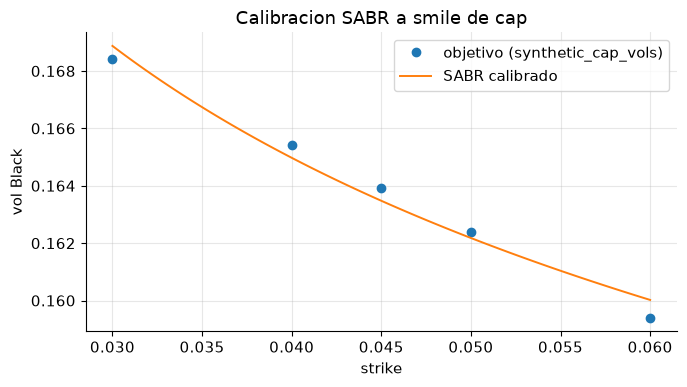

In [6]:
strikes_mkt = np.array([0.03, 0.04, 0.045, 0.05, 0.06])
tenor_mkt = np.array([5.0])
vols_mkt = synthetic_cap_vols(strikes_mkt, tenor_mkt)[0, :]

F_atm = 0.045  # atm_ref de synthetic_cap_vols
beta_fixed = 0.5
T_cal = 5.0


def resid_sabr(params):
    alpha_, rho_, nu_ = params
    if alpha_ <= 0.0 or abs(rho_) >= 1.0 or nu_ <= 0.0:
        return np.full(len(strikes_mkt), 1e3)
    model = np.array([sabr_hagan_vol(F_atm, K, T_cal, alpha_, beta_fixed, rho_, nu_) for K in strikes_mkt])
    return model - vols_mkt


fit = least_squares(resid_sabr, x0=[0.1, -0.3, 0.3], bounds=([1e-4, -0.999, 1e-4], [2.0, 0.999, 3.0]))
alpha_f, rho_f, nu_f = fit.x
vols_fit = np.array([sabr_hagan_vol(F_atm, K, T_cal, alpha_f, beta_fixed, rho_f, nu_f) for K in strikes_mkt])
rel_err_cal = np.abs(vols_fit - vols_mkt) / vols_mkt

print(f"parametros calibrados (beta={beta_fixed} fijo): alpha={alpha_f:.4f}, rho={rho_f:.4f}, nu={nu_f:.4f}")
print(f"vol objetivo:  {np.round(vols_mkt, 5)}")
print(f"vol calibrada: {np.round(vols_fit, 5)}")
print(f"error relativo maximo: {rel_err_cal.max():.4%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(strikes_mkt, vols_mkt, "o", label="objetivo (synthetic_cap_vols)")
K_fine = np.linspace(strikes_mkt.min(), strikes_mkt.max(), 100)
ax.plot(K_fine, [sabr_hagan_vol(F_atm, K, T_cal, alpha_f, beta_fixed, rho_f, nu_f) for K in K_fine],
        label="SABR calibrado")
ax.set_xlabel("strike"); ax.set_ylabel("vol Black"); ax.set_title("Calibracion SABR a smile de cap")
ax.legend(); fig.tight_layout(); plt.show()

## 3. Validación

In [7]:
check1 = max_diff_beta1 < 1e-10
print(f"1. formula general (beta=1) == forma simplificada: max diff={max_diff_beta1:.2e} (<1e-10? {check1})")

check2 = rel_diff_flat.max() < 1e-3
print(f"2. limite rho=0,nu~0 recupera vol plana=alpha: max diff rel={rel_diff_flat.max():.2e} (<1e-3? {check2})")

check3 = rel_err_cal.max() < 0.02
print(f"3. calibracion SABR a smile de cap: error relativo max={rel_err_cal.max():.4%} (<2%? {check3})")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. formula general (beta=1) == forma simplificada: max diff=0.00e+00 (<1e-10? True)
2. limite rho=0,nu~0 recupera vol plana=alpha: max diff rel=1.57e-09 (<1e-3? True)
3. calibracion SABR a smile de cap: error relativo max=0.3861% (<2%? True)

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Hagan, P., Kumar, D., Lesniewski, A., Woodward, D. (2002). *Managing Smile Risk*.
  Wilmott Magazine.
- Obłój, J. (2008). *Fine-tune your smile: correction to Hagan et al*. Wilmott Magazine.